# Tutorial of GlimpsePrune (Qwen2.5VL)

In [1]:
import os
import time
import sys
parent_path = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if parent_path not in sys.path:
    sys.path.append(parent_path)

import torch
from transformers_gp.models.qwen2_5_vl import (
    Qwen2_5_VL_GP_ForConditionalGeneration,
    Qwen2_5_VL_GP_Processor
)
from transformers.generation.configuration_utils import GenerationConfig
from qwen_vl_utils import process_vision_info
from PIL import Image
import matplotlib.pyplot as plt


In [2]:
def apply_mask_on_image(image: Image.Image, 
                        mask: torch.Tensor, 
                        alpha: float=0.4, 
                        color: tuple=(0, 255, 0),
                        patch_size: int=28) -> Image.Image:
    """
    Apply a boolean mask on the image.
    Args:
        image (Image.Image): The input image.
        mask (torch.Tensor): A boolean mask of shape (H, W).
    Returns:
        Image.Image: The blended image with the mask applied.
    """
    mask_h, mask_w = mask.shape
    target_h = mask_h * patch_size
    target_w = mask_w * patch_size
    # resize image and mask
    image = image.resize((target_w, target_h), Image.Resampling.LANCZOS)
    mask = torch.nn.functional.interpolate(
        mask.unsqueeze(0).unsqueeze(0).float(),
        size=(target_h, target_w),
        mode='nearest'
    ).squeeze(0).squeeze(0).bool()

    # apply mask with color and alpha
    mask_image = Image.new('RGBA', image.size, color + (0,))
    alpha_data = (mask * 255 * alpha).byte().cpu().numpy()
    alpha_channel = Image.fromarray(alpha_data, mode='L')
    mask_image.putalpha(alpha_channel)
    blended_image = Image.alpha_composite(image.convert('RGBA'), mask_image)
    return blended_image.convert('RGB')
    

In [ ]:
base_model = "Qwen/Qwen2.5-VL-7B-Instruct"
new_modules_dir = "ashun989/GlimpsePrune_Qwen2.5-VL-7B-Instruct"
show_image_token_masks = True
max_remain_ratio = 0.111

model = Qwen2_5_VL_GP_ForConditionalGeneration.from_pretrained(
    base_model,
    torch_dtype=torch.bfloat16,
    attn_implementation="flash_attention_2",
    device_map={"": "cuda:0"},
)

processor = Qwen2_5_VL_GP_Processor.from_pretrained(
    base_model,
    padding_side="left",
)

model.load_new_modules(new_modules_dir)

model.eval()


In [5]:
if max_remain_ratio is not None:
    model.config.max_remain_ratio = max_remain_ratio

generation_config = GenerationConfig.from_pretrained(
    base_model,
)
generation_config.max_new_tokens = 1024
print("Generation config:", generation_config)

Generation config: GenerationConfig {
  "bos_token_id": 151643,
  "do_sample": true,
  "eos_token_id": [
    151645,
    151643
  ],
  "max_new_tokens": 1024,
  "pad_token_id": 151643,
  "repetition_penalty": 1.05,
  "temperature": 1e-06
}



## 1. Batch Inference

In [6]:
batched_messages = [
    [{
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "../examples/people.png",
            },
            {"type": "text", "text": "What kind of a tie is the groom wearing?"},
        ],
    }],
    [{
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "../examples/court.png",
            },
            {"type": "text", "text": "Who is taking the free throws?"},
        ],
    }],
    [{
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "../examples/shop.jpg",
            },
            {"type": "text", "text": "What do you think this shop is for?"},
        ],
    }],
    [{
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "../examples/food.png",
            },
            {
                "type": "image",
                "image": "../examples/food2.jpg",
            },
            {"type": "text", "text": "Are there any differences between the foods in the two pictures?"},
        ],
    }],
]
    

# Preparation for inference
text = processor.apply_chat_template(
    batched_messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(batched_messages)
batched_inputs = processor(
    text=text,
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
batched_inputs = batched_inputs.to(model.device)

In [9]:
# Inference: Generation of the output
model.reset_image_tokens_cache()  # NOTE: reset the cache before inference
t1 = time.time()
with torch.inference_mode():
    generated_ids = model.generate(**batched_inputs, generation_config=generation_config, do_selection=False)  # Disable glimpse prune by do_selection=False
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(batched_inputs.input_ids, generated_ids)
]
duration = time.time() - t1
print(f"[Original] Total inference time for {len(batched_messages)} samples: {duration:.2f}) seconds")
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
for i, out in enumerate(output_text):
    print(f"[Original] Output {i+1}: {out}")

print(f"max allocated memory: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB")
print(f"max reserved memory: {torch.cuda.max_memory_reserved() / 1024**3:.2f} GB")
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

[Original] Total inference time for 4 samples: 19.88) seconds
[Original] Output 1: The groom is wearing a light-colored, possibly cream or beige, tie with a subtle pattern that appears to be a small, repeating design, which could be floral or abstract. The tie is neatly knotted and complements his black suit jacket.
[Original] Output 2: In the image, the player wearing the number 8 jersey appears to be preparing to take a free throw. The player is standing at the free-throw line, and the ball is in their hands, indicating they are about to shoot. The opposing team's players are positioned around the free-throw line, likely waiting for the shot to be taken.
[Original] Output 3: The image shows an outdoor area with a brick pathway, greenery, and a sign that reads "corepower YOGA." This suggests that the shop or establishment in question is likely a yoga studio or a place offering yoga classes. The sign indicates that they focus on yoga, which is a form of physical, mental, and spiritual 

In [8]:
# Inference: Generation of the output
model.reset_image_tokens_cache()  # NOTE: reset the cache before inference
t1 = time.time()
with torch.inference_mode():
    generated_ids = model.generate(**batched_inputs, generation_config=generation_config, do_selection=True)  # Enable glimpse prune by do_selection=True
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(batched_inputs.input_ids, generated_ids)
]
duration = time.time() - t1
print(f"[GlimpsePrune] Total inference time for {len(batched_messages)} samples: {duration:.2f}) seconds")
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
for i, out in enumerate(output_text):
    print(f"[GlimpsePrune] Output {i+1}: {out}")

print(f"max allocated memory: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB")
print(f"max reserved memory: {torch.cuda.max_memory_reserved() / 1024**3:.2f} GB")
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

[GlimpsePrune] Total inference time for 4 samples: 6.48) seconds
[GlimpsePrune] Output 1: The groom in the picture is wearing a light-colored, possibly cream or beige, tie with a subtle pattern that appears to be a small, repeating design, which could be stripes or dots. The tie has a standard width and knot style, which is typical for formal attire such as a wedding.
[GlimpsePrune] Output 2: In the image, the player wearing the number 8 jersey appears to be preparing to take a free throw. The player is standing at the free-throw line, and the ball is in their hands, indicating they are about to shoot. The other players on the court are positioned as if they are waiting for the shot to be taken.
[GlimpsePrune] Output 3: The image shows the exterior of a shop with a sign that reads "corepower YOGA LIVE POWER." Based on the name and the visible part of the sign, it appears to be a yoga studio or a fitness center that offers yoga classes. The term "corepower" suggests a focus on core stre

## 2. Single Image Inference

In [10]:
messages = batched_messages[0]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(model.device)

if show_image_token_masks:
    image_grid_thw = inputs.image_grid_thw
    attn_hw = image_grid_thw[0, 1:] // 2
    with torch.inference_mode():
        image_token_bool_masks = model(**inputs, do_selection=True).image_token_bool_masks
    image_token_bool_mask = image_token_bool_masks[0].reshape(
        attn_hw[0].item(), attn_hw[1].item()
    )

# Inference: Generation of the output
model.reset_image_tokens_cache()  # NOTE: reset the cache before inference
with torch.inference_mode():
    generated_ids = model.generate(**inputs, generation_config=generation_config, do_selection=True)  # Enable glimpse prune by do_selection=True
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text[0])

torch.cuda.empty_cache()

The groom in the picture is wearing a light-colored, possibly cream or beige, tie with a subtle pattern that appears to be a small, repeating design, which could be stripes or dots. The tie has a standard width and knot style, which is typical for formal attire such as a wedding.


Retain ratio: 2.3%


/tmp/ipykernel_88088/2850961132.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  alpha_channel = Image.fromarray(alpha_data, mode='L')


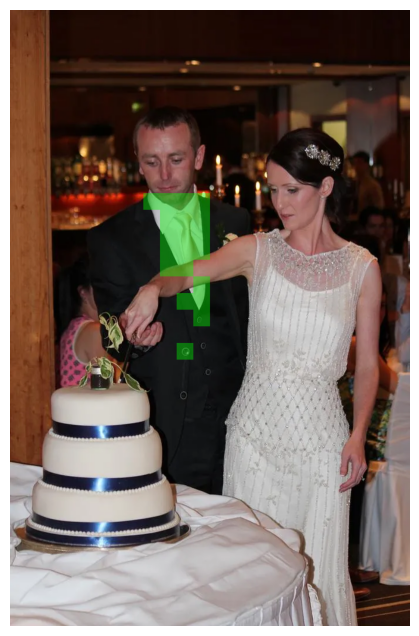

In [11]:
if show_image_token_masks:
    retain_ratio = image_token_bool_mask.float().mean().item()
    print(f"Retain ratio: {retain_ratio*100:.1f}%")

    blended_image = apply_mask_on_image(
        image=Image.open(messages[0]["content"][0]["image"]),
        mask=image_token_bool_mask,
    )

    # Display the blended image
    plt.figure(figsize=(8, 8))
    plt.imshow(blended_image)
    plt.axis("off")
    plt.show()


## 2.Multi Image Inference

In [12]:
messages = batched_messages[-1]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(model.device)

if show_image_token_masks:
    image_grid_thw = inputs.image_grid_thw
    attn_hw = image_grid_thw[:, 1:] // 2
    num_tokens_per_image = torch.prod(attn_hw, dim=1)
    with torch.inference_mode():
        image_token_bool_masks = model(**inputs, do_selection=True).image_token_bool_masks
    image_token_bool_mask_per_image = image_token_bool_masks[0].split(
        num_tokens_per_image.tolist(), dim=0
    )
    num = 0
    image_token_bool_mask_per_image = list(image_token_bool_mask_per_image)
    for i, one_mask in enumerate(image_token_bool_mask_per_image):
        image_token_bool_mask_per_image[i] = one_mask.reshape(
            attn_hw[num, 0].item(), attn_hw[num, 1].item()
        )
        num += 1

# Inference: Generation of the output
model.reset_image_tokens_cache()  # NOTE: reset the cache before inference
with torch.inference_mode():
    generated_ids = model.generate(**inputs, generation_config=generation_config, do_selection=True)  # Enable glimpse prune by do_selection=True
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text[0])

torch.cuda.empty_cache()

Yes, there are significant differences between the foods in the two images:

1. **Image 1 (Pizza):** The food shown is a pizza with various toppings such as sliced tomatoes, green bell peppers, red onions, and possibly some cheese. It appears to be a vegetarian pizza.

2. **Image 2 (Vegetables):** The food here consists of roasted or sautéed vegetables, including carrots and Brussels sprouts. There are no other ingredients visible apart from these vegetables.

In summary, Image 1 features a complete dish (pizza) with multiple toppings, while Image 2 shows only a selection of vegetables without any additional components.


Retain ratio for image 1: 10.7%


/tmp/ipykernel_88088/2850961132.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  alpha_channel = Image.fromarray(alpha_data, mode='L')


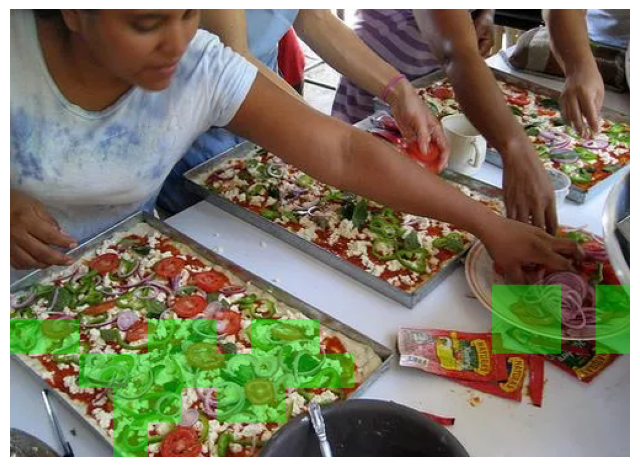

Retain ratio for image 2: 11.0%


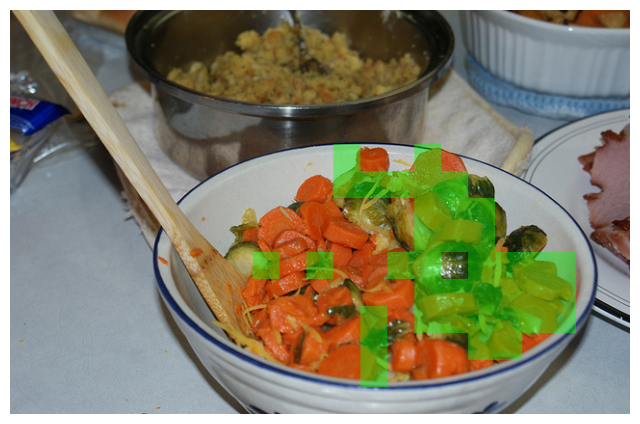

In [13]:
if show_image_token_masks:
    for i, one_mask in enumerate(image_token_bool_mask_per_image):
        retain_ratio = one_mask.float().mean().item()
        print(f"Retain ratio for image {i+1}: {retain_ratio*100:.1f}%")

        
        blended_image = apply_mask_on_image(
            image=Image.open(messages[0]["content"][i]["image"]),
            mask=one_mask,
        )

        # Display the blended image
        plt.figure(figsize=(8, 8))
        plt.imshow(blended_image)
        plt.axis("off")
        plt.show()

## 3. Video Inference


In [1]:
video_messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "video",
                "video": "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen2-VL/space_woaudio.mp4",
                "fps": 1.0,
            },
            {"type": "text", "text": "How many locations appear in the video?"},
        ],
    }
]

# Preparation for video inference
text = processor.apply_chat_template(
    video_messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs, video_kwargs = process_vision_info(
    video_messages, return_video_kwargs=True
)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
    **video_kwargs,
)
inputs = inputs.to(model.device)

kr_config = {
    "frame_redundancy_pooling_mode": "mask",
    "frame_redundancy_min_keep_ratio": 0.1,  # rho in the paper
    "frame_redundancy_min_keep_tokens": 1,
    "frame_redundancy_similarity_threshold": 0.9,  # tau in the paper
}

def run_video_inference(label, *, do_selection, enable_kr):
    model.config.enable_frame_redundancy_merge = enable_kr
    if enable_kr:
        for key, value in kr_config.items():
            setattr(model.config, key, value)
    model.reset_image_tokens_cache()  # NOTE: reset the cache before inference
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    t1 = time.time()
    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            generation_config=generation_config,
            do_selection=do_selection,
        )
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )
    duration = time.time() - t1
    print(f"[{label}] Inference time: {duration:.2f} seconds")
    print(f"[{label}] max allocated memory: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB")
    print(f"[{label}] max reserved memory: {torch.cuda.max_memory_reserved() / 1024**3:.2f} GB")
    print(output_text[0])
    print()

run_video_inference("Original", do_selection=False, enable_kr=False)
run_video_inference("GlimpsePrune", do_selection=True, enable_kr=False)
run_video_inference("GlimpsePrune + KR", do_selection=True, enable_kr=True)

model.config.enable_frame_redundancy_merge = False
torch.cuda.empty_cache()


[Original] Inference time: 10.95 seconds
[Original] max allocated memory: 40.40 GB
[Original] max reserved memory: 52.20 GB
The video primarily takes place inside the International Space Station (ISS). There is also a brief scene that appears to be in a control room or mission control center, which could be part of NASA's facilities on Earth. However, most of the video content is focused on the interior of the ISS and does not show any other locations.

[GlimpsePrune] Inference time: 6.52 seconds
[GlimpsePrune] max allocated memory: 29.43 GB
[GlimpsePrune] max reserved memory: 34.31 GB
The video primarily takes place in one location: inside the International Space Station (ISS). The scenes show various parts of the ISS, including control centers and the interior of the station itself. There is no indication of any other locations being shown in the video.

[GlimpsePrune + KR] Inference time: 5.37 seconds
[GlimpsePrune + KR] max allocated memory: 29.43 GB
[GlimpsePrune + KR] max reserve